In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Curvas 1

In [2]:

# Caminho da pasta com os CSVs
pasta = "./tests/results/mylib"

# Listas para médias
rows = []

In [3]:
# Ler todos os CSV da pasta
for arquivo in os.listdir(pasta):
    if arquivo.endswith('.csv'):
        parts = arquivo.split('-')
        broadphase = '_'.join(parts[2:4])

        collision = parts[4]
        if collision == 'gjk':
            collision = '_'.join(parts[4:6])
            count = parts[6]
        else:
            count = parts[5]

        if count.isnumeric() == False:
            continue

        caminho = os.path.join(pasta, arquivo)

        df = pd.read_csv(caminho)
        rows.append([
            df["collisionsTest"].mean(), 
            df["broadphaseTime"].mean(),
            df["narrowphaseTime"].mean(),
            df["integrationTime"].mean(),
            df["relaxationTime"].mean(),
            df["separationTime"].mean(),
            df["gridClearTime"].mean(),
            df["gridInitTime"].mean(),
            df["gridSortTime"].mean(),
            df["deltatime"].mean(), 
            int(count), 
            broadphase, 
            collision
        ])

In [4]:
df1 = pd.DataFrame(
    rows, 
    columns=[
        "collisions_test", 
        "broadphase_time",
        "narrowphase_time",
        "integration_time",
        "relaxation_time",
        "separation_time",
        "gridClear_time",
        "gridInit_time",
        "gridSort_time",
        "dt", 
        "count", 
        "broadphase", 
        "narrowphase"
        ]
    )


In [5]:
styles = {
    ("naive_mode", "sat"): {"linestyle": "-", "marker": "o"},
    ("grid_mode", "sat"): {"linestyle": "-", "marker": "o"},
    ("naive_mode", "gjk_epa"): {"linestyle": "--", "marker": "s"},
    ("grid_mode", "gjk_epa"): {"linestyle": "--", "marker": "s"},
}

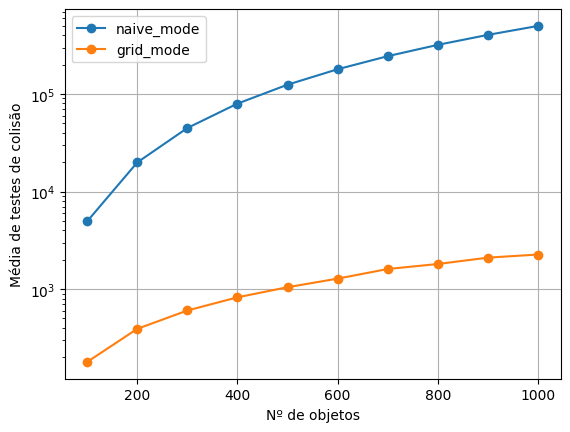

In [6]:
fig, ax = plt.subplots()

for broadphase in ["naive_mode", "grid_mode"]:
    g = df1[
        (df1["broadphase"] == broadphase) & 
        (df1["narrowphase"] == "sat")
    ].sort_values("count")

    style = styles[(broadphase, "sat")]

    ax.plot(
        g["count"],
        g["collisions_test"],
        label=broadphase,
        linestyle=style["linestyle"],
        marker=style["marker"]
    )

ax.set_xlabel("Nº de objetos")
ax.set_ylabel("Média de testes de colisão")
ax.set_yscale("log")
ax.legend()
ax.grid()

plt.show()

## Curvas 2

In [7]:

# Caminho da pasta com os CSVs
pasta = "./tests/results/box2d"

# Listas para médias
rows = []

In [8]:
# Ler todos os CSV da pasta
for arquivo in os.listdir(pasta):
    if arquivo.endswith('.csv'):
        parts = arquivo.split('-')
        count = parts[1]
        if count.isnumeric() is False:
            continue

        caminho = os.path.join(pasta, arquivo)

        df = pd.read_csv(caminho)
        rows.append([
            # df["true_collisions"].mean(), 
            df["dt"].mean(), 
            int(count)
        ])

In [9]:
df2 = pd.DataFrame(rows, columns=["dt", "count"])
df2 = df2.sort_values("count")

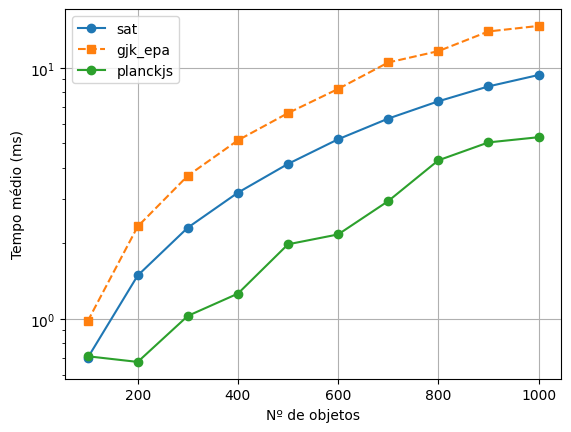

In [10]:
fig, ax = plt.subplots()

for narrowphase in ["sat", "gjk_epa"]:
    g = df1[
            (df1["narrowphase"] == narrowphase) & 
            (df1["broadphase"] == "grid_mode")
        ].sort_values("count")
    
    style = styles[("grid_mode", narrowphase)]

    ax.plot(
        g["count"],
        g["dt"],
        label=narrowphase,
        linestyle=style["linestyle"],
        marker=style["marker"]
    )

ax.plot(df2["count"], df2["dt"], label="planckjs", marker="o")

ax.set_xlabel("Nº de objetos")
ax.set_ylabel("Tempo médio (ms)")
ax.set_yscale("log")
ax.legend()
ax.grid()

plt.show()

## Curvas 3

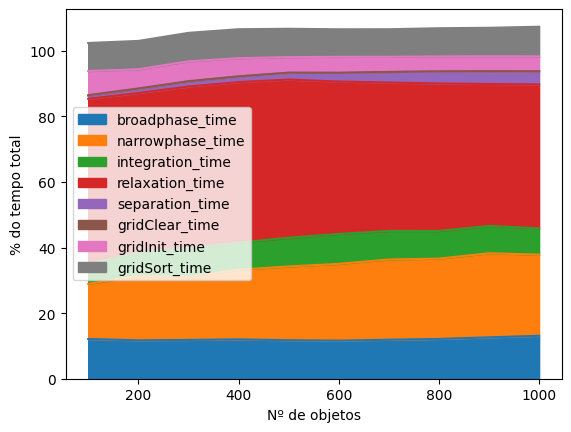

In [15]:
cols = [
    "broadphase_time",
    "narrowphase_time",
    "integration_time",
    "relaxation_time",
    "separation_time",
    "gridClear_time",
    "gridInit_time",
    "gridSort_time"
]

g = df1[
    (df1["broadphase"] == "grid_mode") & 
    (df1["narrowphase"] == "sat")
].sort_values("count")

# calcula porcentagens de uma vez
rel = g[cols].div(g["dt"], axis=0) * 100

# plota tudo de uma vez
ax = rel.set_index(g["count"]).plot.area()

ax.set_xlabel("Nº de objetos")
ax.set_ylabel("% do tempo total")
plt.show()